Working directory: C:\Users\HP\Desktop\rag-complaint-chatbot
Loading dataset...
Dataset shape: (9609797, 18)

Columns:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

First 3 rows:
  Date received                                            Product  \
0    2025-06-20  Credit reporting or other personal consumer re...   
1    2025-06-20                                    Debt collection   
2    2025-06-20  Credit reporting or other personal consumer re...   

               Sub-product                                 Issue  \
0         Credit reporting  Incorrect information on your report   
1  Telecommunications debt     Attempts to collect debt not owed   
2         Credit reporting           Improper use of yo

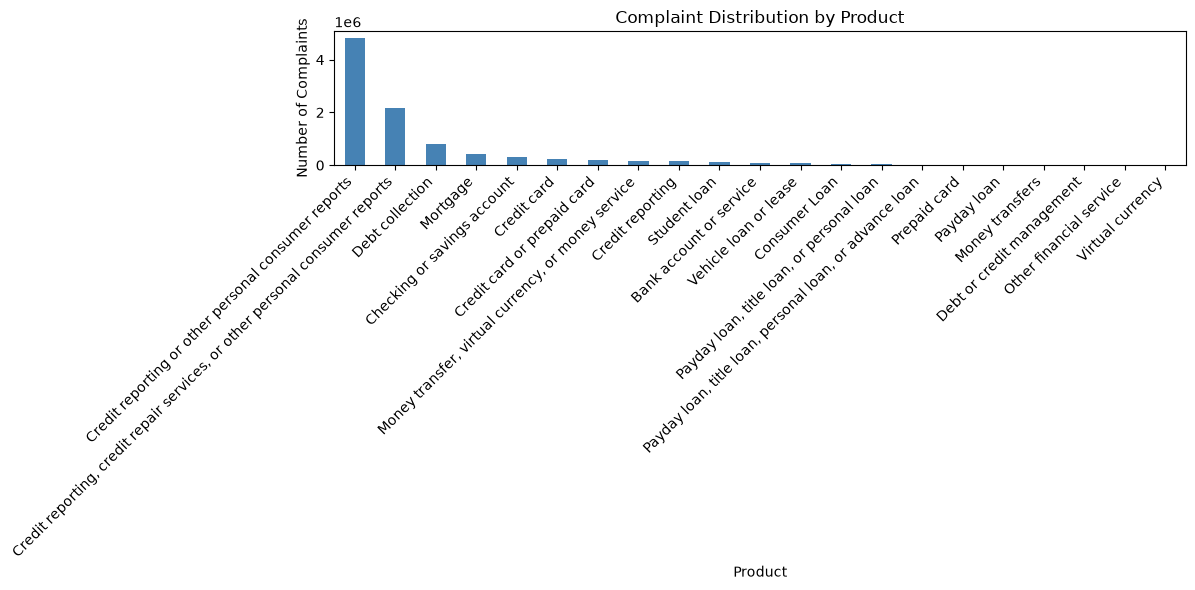

Saved: data/processed/product_distribution.png

Narrative word count stats:
count    9.609797e+06
mean     5.446667e+01
std      1.497672e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: narrative_word_count, dtype: float64


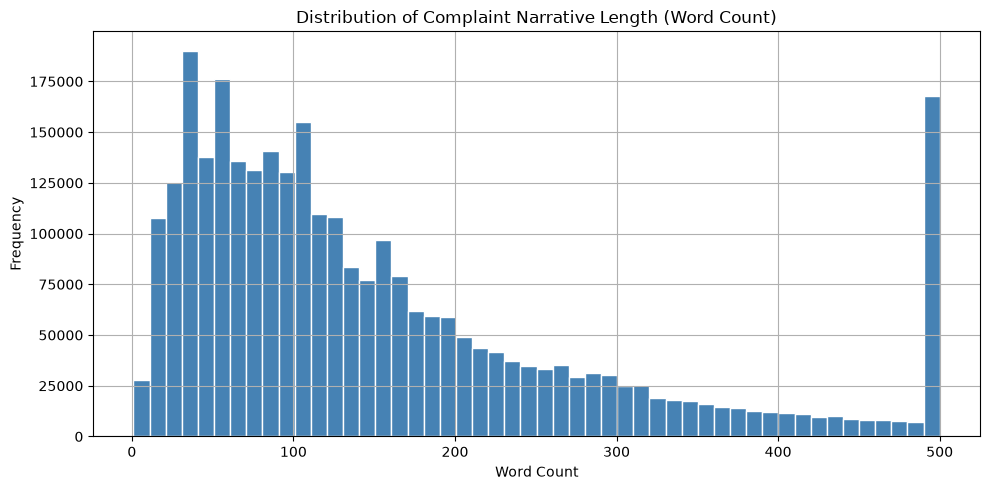

Saved: data/processed/narrative_length_distribution.png

Complaints WITH narrative: 2980756
Complaints WITHOUT narrative: 6629041


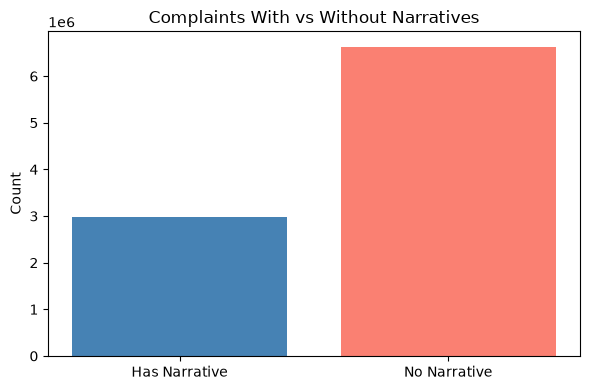

Saved: data/processed/narrative_presence.png

============ FILTERING ============

All unique products in dataset:
<StringArray>
[                         'Credit reporting or other personal consumer reports',
                                                              'Debt collection',
                                                                  'Credit card',
                                                  'Checking or savings account',
                           'Money transfer, virtual currency, or money service',
                                                        'Vehicle loan or lease',
                                                    'Debt or credit management',
                                                                     'Mortgage',
                      'Payday loan, title loan, personal loan, or advance loan',
                                                                 'Prepaid card',
                                                             

In [13]:
# ============================================================
# Task 1: Exploratory Data Analysis and Data Preprocessing
# CrediTrust Financial - RAG Complaint Chatbot
# ============================================================
import os
os.chdir(r'C:\Users\HP\Desktop\rag-complaint-chatbot')
print("Working directory:", os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# ── 1. LOAD DATA ────────────────────────────────────────────
print("Loading dataset...")

DATA_PATH = "data/raw/complaints_data.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 3 rows:\n{df.head(3)}")


# ── 2. INITIAL EDA ──────────────────────────────────────────
print("\n============ EDA ============")

print("\nProduct distribution:")
print(df['Product'].value_counts())

plt.figure(figsize=(12, 6))
df['Product'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Complaint Distribution by Product')
plt.xlabel('Product')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
os.makedirs("data/processed", exist_ok=True)
plt.savefig("data/processed/product_distribution.png")
plt.show()
print("Saved: data/processed/product_distribution.png")

narrative_col = 'Consumer complaint narrative'

df['narrative_word_count'] = df[narrative_col].fillna('').apply(
    lambda x: len(str(x).split())
)

print(f"\nNarrative word count stats:")
print(df['narrative_word_count'].describe())

plt.figure(figsize=(10, 5))
df[df['narrative_word_count'] > 0]['narrative_word_count'].clip(upper=500).hist(
    bins=50, color='steelblue', edgecolor='white'
)
plt.title('Distribution of Complaint Narrative Length (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("data/processed/narrative_length_distribution.png")
plt.show()
print("Saved: data/processed/narrative_length_distribution.png")

has_narrative = df[narrative_col].notna().sum()
no_narrative = df[narrative_col].isna().sum()
print(f"\nComplaints WITH narrative: {has_narrative}")
print(f"Complaints WITHOUT narrative: {no_narrative}")

plt.figure(figsize=(6, 4))
plt.bar(['Has Narrative', 'No Narrative'], [has_narrative, no_narrative],
        color=['steelblue', 'salmon'])
plt.title('Complaints With vs Without Narratives')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("data/processed/narrative_presence.png")
plt.show()
print("Saved: data/processed/narrative_presence.png")


# ── 3. FILTER DATASET ───────────────────────────────────────
print("\n============ FILTERING ============")

print(f"\nAll unique products in dataset:")
print(df['Product'].unique())

target_products = [
    'Credit card',
    'Credit card or prepaid card',
    'Personal loan',
    'Payday loan, title loan, or personal loan',
    'Checking or savings account',
    'Money transfer, virtual currency, or money service',
    'Money transfers'
]

df_filtered = df[df['Product'].isin(target_products)].copy()
df_filtered = df_filtered[df_filtered[narrative_col].notna()].copy()
df_filtered = df_filtered[df_filtered[narrative_col].str.strip() != ''].copy()

print(f"\nAfter filtering:")
print(f"Shape: {df_filtered.shape}")
print(f"\nProduct counts after filter:")
print(df_filtered['Product'].value_counts())


# ── 4. MAP TO 4 CATEGORIES ──────────────────────────────────
print("\n============ MAPPING PRODUCTS ============")

def map_product(product):
    product = str(product).lower()
    if 'credit card' in product or 'prepaid card' in product:
        return 'Credit Card'
    elif 'personal loan' in product or 'payday loan' in product:
        return 'Personal Loan'
    elif 'saving' in product or 'checking' in product:
        return 'Savings Account'
    elif 'money transfer' in product or 'virtual currency' in product:
        return 'Money Transfer'
    else:
        return 'Other'

df_filtered['product_category'] = df_filtered['Product'].apply(map_product)
df_filtered = df_filtered[df_filtered['product_category'] != 'Other'].copy()

print(f"\nFinal product categories:")
print(df_filtered['product_category'].value_counts())


# ── 5. CLEAN TEXT ───────────────────────────────────────────
print("\n============ CLEANING TEXT ============")

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    boilerplate = [
        r'i am writing to file a complaint',
        r'i am writing to complain',
        r'to whom it may concern',
        r'xxxx',
        r'xx/xx/xxxx',
        r'xx/xx/xx',
    ]
    for phrase in boilerplate:
        text = re.sub(phrase, '', text)
    text = re.sub(r'[^a-z0-9\s\.\,\!\?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning narratives (this may take a few minutes)...")
df_filtered['cleaned_narrative'] = df_filtered[narrative_col].apply(clean_text)
df_filtered = df_filtered[df_filtered['cleaned_narrative'].str.strip() != ''].copy()

print(f"\nShape after cleaning: {df_filtered.shape}")
print(f"\nSample cleaned narrative:")
print(df_filtered['cleaned_narrative'].iloc[0][:300])


# ── 6. SAVE CLEANED DATASET ─────────────────────────────────
print("\n============ SAVING ============")

output_path = "data/processed/filtered_complaints.csv"

cols_to_keep = [
    'Complaint ID',
    'Product',
    'product_category',
    'Issue',
    'Sub-issue',
    'Consumer complaint narrative',
    'cleaned_narrative',
    'Company',
    'State',
    'Date received'
]

cols_to_keep = [c for c in cols_to_keep if c in df_filtered.columns]
df_final = df_filtered[cols_to_keep].copy()

df_final.to_csv(output_path, index=False)
print(f"Saved filtered dataset to: {output_path}")
print(f"Final shape: {df_final.shape}")
print("\n✅ Task 1 Complete!")